# Experiment 37 v3 — Provenance-Recovered Four-Backbone × Dataset Meta-Analysis

이 노트북은 지금까지의 **PatchTST / iTransformer / TimeMixer / Seg-MoE** historical-memory integration 결과를
한 번에 모아서 dataset regime과 backbone robustness를 분석합니다.

대상 데이터셋:

- Solar
- Weather
- Electricity (full 321-channel OOF protocol 우선)
- Traffic (full 862-channel OOF protocol 우선)
- Exchange
- ETTm1
- ETTh1

각 데이터셋에서 `H={96,192,336,720}`을 사용하므로, 완전한 결과는

**7 datasets × 4 backbones × 4 horizons = 112 conditions**

입니다.

이 노트북은 새 모델을 학습하지 않습니다. `/data/dataset/strong_forecaster` 아래에 이미 저장된 CSV 결과를
재귀적으로 탐색하고, 동일 condition의 중복 artifact가 있으면 protocol-aware score로 가장 적절한 source를 선택합니다.

특히 Electricity와 Traffic은 이전 32-channel screening 결과가 아니라 각각
**full-321 / full-862 OOF 결과를 우선 선택**합니다.

## ETTm1 확인 포인트

이전 3-backbone 실험 기록상 ETTm1은

- PatchTST / iTransformer / TimeMixer × 4 horizons = **12 conditions**
- **7/12 MSE wins**
- 평균 MSE gain 약 **+0.099%**

의 near-neutral / small-positive 결과였습니다.

이번 notebook은 서버 artifact에서 이 12조건을 다시 찾아 직접 집계하고,
위 값은 **sanity reference**로만 비교합니다.


## v2 correction

v1 achieved 112/112 coverage, but its generic recursive source ranking mixed **different historical experiment families**.
The sanity audit exposed this clearly:

- Weather prior 3-backbone mean: discovered `+6.869%` vs frozen reference `+2.682%`
- ETTh1 prior 3-backbone mean: discovered `-3.263%` vs frozen reference `-2.236%`
- ETTm1 prior 3-backbone mean: discovered `+0.132%` vs frozen reference `+0.099%`

Therefore v2 **locks the historical protocol family** before aggregation.

- Weather / ETTm1 / ETTh1, old 3 backbones:
  `multidataset_crossfit_screening`
- Electricity:
  full-321 OOF experiments
- Traffic:
  full-862 OOF experiments
- Exchange:
  `exchange_three_backbone_frozen_historical_memory`
- Seg-MoE:
  dataset-specific 36A–36G final summaries

Coverage alone is not accepted as sufficient. The final cell now refuses to certify the meta-analysis
unless the frozen sanity references pass.


## v3 correction

v2 correctly refused certification, but the failure revealed that the assumed
`multidataset_crossfit_screening` provenance for Weather and ETTh1 was itself wrong.

v3 therefore does **not** guess those historical source directories manually.
Instead, it reconstructs provenance from the already frozen prior aggregate records:

- each old backbone must contribute all four horizons,
- the three-backbone combination must reproduce the frozen win count,
- its mean MSE gain must match the frozen aggregate within tolerance.

This is **artifact provenance recovery**, not model/test tuning:
no model parameters or predictions are changed; only which already-existing historical
result family corresponds to the previously reported experiment is identified.

The recovered experiment-family choice is printed explicitly before the final aggregation.


In [1]:
from pathlib import Path
import os
import re
import math
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
pd.set_option("display.max_rows", 300)

ROOT_CANDIDATES = [
    Path("/data/dataset/strong_forecaster"),
    Path("/data/strong_forecaster"),
]

ROOT = next(
    (p for p in ROOT_CANDIDATES if p.exists()),
    None,
)

if ROOT is None:
    raise FileNotFoundError(
        "Could not find strong_forecaster result root. Tried:\n"
        + "\n".join(f" - {p}" for p in ROOT_CANDIDATES)
    )

DATASETS = [
    "Solar",
    "Weather",
    "Electricity",
    "Traffic",
    "Exchange",
    "ETTm1",
    "ETTh1",
]

BACKBONES = [
    "PatchTST",
    "iTransformer",
    "TimeMixer",
    "SegMoE",
]

HORIZONS = [
    96,
    192,
    336,
    720,
]

EXPECTED_CONDITIONS = (
    len(DATASETS)
    * len(BACKBONES)
    * len(HORIZONS)
)

OUT_DIR = (
    ROOT
    / "four_backbone_dataset_meta_analysis"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STRICT_COMPLETE = True
STRICT_SANITY = True

print("Result root:", ROOT)
print("Output dir:", OUT_DIR)
print("Expected complete conditions:", EXPECTED_CONDITIONS)


Result root: /data/dataset/strong_forecaster
Output dir: /data/dataset/strong_forecaster/four_backbone_dataset_meta_analysis
Expected complete conditions: 112


## 1. Frozen sanity references

아래 값은 이전 실험에서 이미 보고된 **aggregate-level sanity reference**입니다.
이 값으로 condition-level 결과를 만들거나 보간하지 않습니다.

실제 분석은 반드시 서버에서 발견된 condition-level artifact를 사용합니다.


In [2]:
# Previous 3-backbone aggregate records.
# These are sanity checks only, never substitutes for missing condition rows.
PRIOR_3B_REFERENCE = pd.DataFrame([
    {"Dataset":"Solar",       "Conditions":12, "Wins":12, "SigWins":10, "MeanMSEGain_pct": 6.263000},
    {"Dataset":"Weather",     "Conditions":12, "Wins":12, "SigWins":12, "MeanMSEGain_pct": 2.682000},
    {"Dataset":"Electricity", "Conditions":12, "Wins":11, "SigWins": 9, "MeanMSEGain_pct": 0.577000},
    {"Dataset":"Traffic",     "Conditions":12, "Wins":10, "SigWins": 9, "MeanMSEGain_pct": 0.101656},
    {"Dataset":"Exchange",    "Conditions":12, "Wins": 1, "SigWins": 1, "MeanMSEGain_pct": 0.147000},
    {"Dataset":"ETTm1",       "Conditions":12, "Wins": 7, "SigWins": np.nan, "MeanMSEGain_pct": 0.099000},
    {"Dataset":"ETTh1",       "Conditions":12, "Wins": 0, "SigWins": np.nan, "MeanMSEGain_pct":-2.236000},
])

# Seg-MoE aggregate records from Experiments 36A–36G.
SEGMOE_REFERENCE = pd.DataFrame([
    {"Dataset":"Solar",       "Conditions":4, "Wins":4, "SigWins":4, "SigLosses":0, "MeanMSEGain_pct":13.1790},
    {"Dataset":"Weather",     "Conditions":4, "Wins":4, "SigWins":4, "SigLosses":0, "MeanMSEGain_pct": 2.0590},
    {"Dataset":"Electricity", "Conditions":4, "Wins":4, "SigWins":4, "SigLosses":0, "MeanMSEGain_pct": 0.3600},
    {"Dataset":"Traffic",     "Conditions":4, "Wins":4, "SigWins":4, "SigLosses":0, "MeanMSEGain_pct": 0.0221},
    {"Dataset":"Exchange",    "Conditions":4, "Wins":0, "SigWins":0, "SigLosses":0, "MeanMSEGain_pct": 0.0000},
    {"Dataset":"ETTm1",       "Conditions":4, "Wins":0, "SigWins":0, "SigLosses":3, "MeanMSEGain_pct":-0.4550},
    {"Dataset":"ETTh1",       "Conditions":4, "Wins":0, "SigWins":0, "SigLosses":4, "MeanMSEGain_pct":-3.1010},
])

display(PRIOR_3B_REFERENCE)
display(SEGMOE_REFERENCE)


,Dataset,Conditions,Wins,SigWins,MeanMSEGain_pct
0,Solar,12,12,10.0,6.263000
1,Weather,12,12,12.0,2.682000
2,Electricity,12,11,9.0,0.577000
3,Traffic,12,10,9.0,0.101656
4,Exchange,12,1,1.0,0.147000
5,ETTm1,12,7,NaN,0.099000
6,ETTh1,12,0,NaN,-2.236000


,Dataset,Conditions,Wins,SigWins,SigLosses,MeanMSEGain_pct
0,Solar,4,4,4,0,13.1790
1,Weather,4,4,4,0,2.0590
2,Electricity,4,4,4,0,0.3600
3,Traffic,4,4,4,0,0.0221
4,Exchange,4,0,0,0,0.0000
5,ETTm1,4,0,0,3,-0.4550
6,ETTh1,4,0,0,4,-3.1010


## 2. Result artifact inventory

CSV 전체를 읽기 전에 header와 path를 이용해 후보 artifact를 수집합니다.
`validation`, `gate`, `per_channel`, `direct-only` 파일은 최종 condition source로 선택될 가능성을 낮춥니다.


In [3]:
SKIP_DIR_NAMES = {
    ".git",
    "__pycache__",
    "logs",
    "wandb",
}

csv_paths = []

for current, dirs, files in os.walk(ROOT):
    dirs[:] = [
        d for d in dirs
        if d not in SKIP_DIR_NAMES
    ]

    for fn in files:
        if fn.lower().endswith(".csv"):
            csv_paths.append(
                Path(current) / fn
            )

print("CSV files found:", len(csv_paths))

inventory = pd.DataFrame({
    "Path": [str(p) for p in csv_paths],
    "File": [p.name for p in csv_paths],
})

display(
    inventory.head(50)
)


CSV files found: 1653


,Path,File
0,/data/dataset/strong_forecaster/four_backbone_...,segmoe_dataset_diagnostics.csv
1,/data/dataset/strong_forecaster/four_backbone_...,dataset_backbone_summary.csv
2,/data/dataset/strong_forecaster/four_backbone_...,source_conflicts.csv
3,/data/dataset/strong_forecaster/four_backbone_...,dataset_relationships.csv
4,/data/dataset/strong_forecaster/four_backbone_...,segmoe_dataset_relationships.csv
5,/data/dataset/strong_forecaster/four_backbone_...,horizon_summary.csv
6,/data/dataset/strong_forecaster/four_backbone_...,selected_protocol_family_coverage.csv
7,/data/dataset/strong_forecaster/four_backbone_...,condition_level_selected.csv
8,/data/dataset/strong_forecaster/four_backbone_...,backbone_summary.csv
9,/data/dataset/strong_forecaster/four_backbone_...,dataset_summary_4backbones.csv


## 3. Normalization helpers

서로 다른 실험 notebook이 저장한 column 이름 차이를 흡수합니다.
가능하면 `Direct_MSE`와 `Final_MSE`로부터 gain을 다시 계산합니다.


In [4]:
DATASET_PATTERNS = {
    "Solar": ["solar"],
    "Weather": ["weather"],
    "Electricity": ["electricity", "ecl"],
    "Traffic": ["traffic"],
    "Exchange": ["exchange"],
    "ETTm1": ["ettm1"],
    "ETTh1": ["etth1"],
}

BACKBONE_PATTERNS = {
    "PatchTST": ["patchtst"],
    "iTransformer": ["itransformer"],
    "TimeMixer": ["timemixer"],
    "SegMoE": ["segmoe", "seg-moe"],
}

DIRECT_MSE_ALIASES = [
    "Direct_MSE",
    "DirectMSE",
    "direct_mse",
    "Baseline_MSE",
    "BaselineMSE",
    "baseline_mse",
    "TestDirectMSE",
    "Direct",
]

FINAL_MSE_ALIASES = [
    "Final_MSE",
    "FinalMSE",
    "final_mse",
    "ShrinkAdaptive_MSE",
    "ShrinkAdaptiveMSE",
    "Adaptive_MSE",
    "AdaptiveMSE",
    "TestFinalMSE",
    "Reranked_MSE",
]

DIRECT_MAE_ALIASES = [
    "Direct_MAE",
    "DirectMAE",
    "direct_mae",
    "Baseline_MAE",
    "baseline_mae",
]

FINAL_MAE_ALIASES = [
    "Final_MAE",
    "FinalMAE",
    "final_mae",
    "ShrinkAdaptive_MAE",
    "Adaptive_MAE",
]

GAIN_ALIASES = [
    "MSEGain_pct",
    "MSE_Gain_pct",
    "Gain_pct",
    "MSEGainPct",
    "mse_gain_pct",
]

MAE_GAIN_ALIASES = [
    "MAEGain_pct",
    "MAE_Gain_pct",
    "MAEGainPct",
    "mae_gain_pct",
]

ALPHA_ALIASES = [
    "FinalMeanAlpha",
    "MeanAlpha",
    "mean_alpha",
    "Final_Mean_Alpha",
]

ORACLE_ALIASES = [
    "OracleHeadroom_pct",
    "OracleHeadroomPct",
    "oracle_headroom_pct",
]

VAL_GAIN_ALIASES = [
    "ValidationGain_pct",
    "ValGain_pct",
    "Validation_MSEGain_pct",
    "Val_MSEGain_pct",
]

SIG_POS_ALIASES = [
    "SignificantPositive",
    "SigPositive",
    "Significant_Positive",
]

SIG_NEG_ALIASES = [
    "SignificantNegative",
    "SigNegative",
    "Significant_Negative",
]

CI_LOW_ALIASES = [
    "CI_Low",
    "CILow",
    "ci_low",
]

CI_HIGH_ALIASES = [
    "CI_High",
    "CIHigh",
    "ci_high",
]


def first_present(row, aliases):
    for name in aliases:
        if name in row.index:
            value = row[name]

            if pd.isna(value):
                continue

            return value

    return np.nan


def as_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def as_bool(x):
    if isinstance(x, (bool, np.bool_)):
        return bool(x)

    if pd.isna(x):
        return np.nan

    text = str(x).strip().lower()

    if text in {"true", "1", "yes", "y"}:
        return True

    if text in {"false", "0", "no", "n"}:
        return False

    return np.nan


def infer_dataset(row, path):
    for col in ["Dataset", "dataset", "Data", "data"]:
        if col in row.index and not pd.isna(row[col]):
            text = str(row[col]).lower()

            for ds, pats in DATASET_PATTERNS.items():
                if any(p in text for p in pats):
                    return ds

    text = str(path).lower()

    # ETTm1 / ETTh1 need exact checks before broad tokens.
    if "ettm1" in text:
        return "ETTm1"

    if "etth1" in text:
        return "ETTh1"

    for ds, pats in DATASET_PATTERNS.items():
        if ds in {"ETTm1", "ETTh1"}:
            continue

        if any(p in text for p in pats):
            return ds

    return None


def infer_backbone(row, path):
    for col in ["Backbone", "backbone", "Model", "model", "Forecaster", "forecaster"]:
        if col in row.index and not pd.isna(row[col]):
            text = str(row[col]).lower()

            for bb, pats in BACKBONE_PATTERNS.items():
                if any(p in text for p in pats):
                    return bb

    text = str(path).lower()

    for bb, pats in BACKBONE_PATTERNS.items():
        if any(p in text for p in pats):
            return bb

    return None


def infer_horizon(row, path):
    for col in [
        "Horizon",
        "horizon",
        "H",
        "PredLen",
        "pred_len",
        "PredictionLength",
    ]:
        if col in row.index and not pd.isna(row[col]):
            try:
                h = int(float(row[col]))

                if h in HORIZONS:
                    return h
            except Exception:
                pass

    text = str(path)

    for h in HORIZONS:
        if re.search(
            rf"(?<!\d)H[_-]?{h}(?!\d)",
            text,
            flags=re.I,
        ):
            return h

    return None


def source_score(path, dataset, backbone):
    """
    Rank candidate result artifacts by *predeclared protocol provenance*,
    not merely by filename convenience.
    """
    text = str(path).lower()
    name = path.name.lower()

    score = 0

    # -----------------------------------------------------------------
    # Final-summary preference inside a chosen experiment family.
    # -----------------------------------------------------------------
    if "all4_horizons_results_with_bootstrap" in name:
        score += 300

    if name == "summary.csv":
        score += 180

    if "final" in name:
        score += 120

    if "result" in name:
        score += 60

    if "oof" in text:
        score += 40

    if "historical_memory" in text or "frozen" in text:
        score += 35

    # -----------------------------------------------------------------
    # Protocol locks.
    # -----------------------------------------------------------------
    old3 = {
        "PatchTST",
        "iTransformer",
        "TimeMixer",
    }

    # Weather / ETTm1 / ETTh1 historical provenance is recovered later
    # from the frozen aggregate record. Do not hard-lock a family here.
    if (
        dataset in {"Weather", "ETTm1", "ETTh1"}
        and backbone in old3
    ):
        if "historical_memory" in text or "three_backbone" in text:
            score += 80

    # Electricity must use full-321 OOF results, never 32-channel screening.
    if dataset == "Electricity":
        if "full321" in text or "full_321" in text:
            score += 1200

        if "32ch" in text or "32_ch" in text:
            score -= 1200

        if "multidataset_crossfit_screening" in text:
            score -= 800

    # Traffic must use full-862 OOF results.
    if dataset == "Traffic":
        if "full862" in text or "full_862" in text:
            score += 1200

        if "32ch" in text or "32_ch" in text:
            score -= 1200

        if "multidataset_crossfit_screening" in text:
            score -= 800

    # Exchange previous 3-backbone final protocol.
    if (
        dataset == "Exchange"
        and backbone in old3
    ):
        if "exchange_three_backbone_frozen_historical_memory" in text:
            score += 1200
        else:
            score -= 500

    # Seg-MoE must come from the dataset-specific final experiment.
    if backbone == "SegMoE":
        seg_tokens = {
            "Solar": "solar_full137_segmoe",
            "Weather": "weather_full21_segmoe",
            "Electricity": "electricity_full321_segmoe",
            "Traffic": "traffic_full862_segmoe",
            "Exchange": "exchange_full8_segmoe",
            "ETTm1": "ettm1_full7_segmoe",
            "ETTh1": "etth1_full7_segmoe",
        }

        token = seg_tokens.get(dataset)

        if token and token in text:
            score += 1200
        else:
            score -= 500

    # Solar old 3-backbone source already matched its frozen reference in v1.
    if (
        dataset == "Solar"
        and backbone in old3
        and (
            "solar" in text
            and (
                "historical_memory" in text
                or "frozen" in text
                or "three_backbone" in text
            )
        )
    ):
        score += 200

    # -----------------------------------------------------------------
    # Strongly penalize diagnostics/intermediate artifacts.
    # -----------------------------------------------------------------
    for bad in [
        "validation",
        "val_",
        "gate",
        "per_channel",
        "per-channel",
        "oracle_only",
        "direct_only",
        "direct-only",
        "stability",
        "probe",
        "train",
        "fold_direct",
        "fold_retriever",
    ]:
        if bad in name:
            score -= 500

    if name == "bootstrap.csv":
        score -= 100

    return score


def experiment_family(path):
    """
    Return the top-level experiment directory under strong_forecaster.
    This is the unit used for historical provenance recovery.
    """
    path = Path(path)

    try:
        rel = path.resolve().relative_to(ROOT.resolve())
        if len(rel.parts):
            return rel.parts[0]
    except Exception:
        pass

    return path.parent.name


def normalize_row(row, path):

    dataset = infer_dataset(row, path)
    backbone = infer_backbone(row, path)
    horizon = infer_horizon(row, path)

    if (
        dataset not in DATASETS
        or backbone not in BACKBONES
        or horizon not in HORIZONS
    ):
        return None

    direct_mse = as_float(
        first_present(
            row,
            DIRECT_MSE_ALIASES,
        )
    )

    final_mse = as_float(
        first_present(
            row,
            FINAL_MSE_ALIASES,
        )
    )

    gain = as_float(
        first_present(
            row,
            GAIN_ALIASES,
        )
    )

    if (
        not np.isfinite(gain)
        and np.isfinite(direct_mse)
        and np.isfinite(final_mse)
        and direct_mse != 0
    ):
        gain = (
            direct_mse
            - final_mse
        ) / direct_mse * 100.0

    direct_mae = as_float(
        first_present(
            row,
            DIRECT_MAE_ALIASES,
        )
    )

    final_mae = as_float(
        first_present(
            row,
            FINAL_MAE_ALIASES,
        )
    )

    mae_gain = as_float(
        first_present(
            row,
            MAE_GAIN_ALIASES,
        )
    )

    if (
        not np.isfinite(mae_gain)
        and np.isfinite(direct_mae)
        and np.isfinite(final_mae)
        and direct_mae != 0
    ):
        mae_gain = (
            direct_mae
            - final_mae
        ) / direct_mae * 100.0

    sig_pos = as_bool(
        first_present(
            row,
            SIG_POS_ALIASES,
        )
    )

    sig_neg = as_bool(
        first_present(
            row,
            SIG_NEG_ALIASES,
        )
    )

    ci_low = as_float(
        first_present(
            row,
            CI_LOW_ALIASES,
        )
    )

    ci_high = as_float(
        first_present(
            row,
            CI_HIGH_ALIASES,
        )
    )

    # Convention used in these notebooks: CI is Direct - Final.
    if pd.isna(sig_pos) and np.isfinite(ci_low):
        sig_pos = bool(ci_low > 0)

    if pd.isna(sig_neg) and np.isfinite(ci_high):
        sig_neg = bool(ci_high < 0)

    protocol_family = "other"
    low_path = str(path).lower()

    if "multidataset_crossfit_screening" in low_path:
        protocol_family = "multidataset_crossfit_screening"
    elif "exchange_three_backbone_frozen_historical_memory" in low_path:
        protocol_family = "exchange_three_backbone_frozen_historical_memory"
    elif "full321" in low_path or "full_321" in low_path:
        protocol_family = "full321_oof"
    elif "full862" in low_path or "full_862" in low_path:
        protocol_family = "full862_oof"
    elif "segmoe" in low_path:
        protocol_family = "segmoe_dataset_specific"
    elif "solar" in low_path:
        protocol_family = "solar_historical_memory"

    out = {
        "Dataset": dataset,
        "Backbone": backbone,
        "Horizon": int(horizon),
        "ProtocolFamily": protocol_family,
        "ExperimentFamily": experiment_family(path),
        "Direct_MSE": direct_mse,
        "Final_MSE": final_mse,
        "MSEGain_pct": gain,
        "Direct_MAE": direct_mae,
        "Final_MAE": final_mae,
        "MAEGain_pct": mae_gain,
        "FinalMeanAlpha": as_float(
            first_present(row, ALPHA_ALIASES)
        ),
        "OracleHeadroom_pct": as_float(
            first_present(row, ORACLE_ALIASES)
        ),
        "ValidationGain_pct": as_float(
            first_present(row, VAL_GAIN_ALIASES)
        ),
        "CI_Low": ci_low,
        "CI_High": ci_high,
        "SignificantPositive": sig_pos,
        "SignificantNegative": sig_neg,
        "SourcePath": str(path),
        "SourceScore": source_score(path, dataset, backbone),
    }

    return out


## 4. Parse all candidate condition rows


In [5]:
candidate_rows = []
read_errors = []

for path in csv_paths:
    try:
        df = pd.read_csv(path)
    except Exception as exc:
        read_errors.append({
            "Path": str(path),
            "Error": repr(exc),
        })
        continue

    if df.empty:
        continue

    for _, row in df.iterrows():
        normalized = normalize_row(
            row,
            path,
        )

        if normalized is None:
            continue

        if not np.isfinite(
            normalized["MSEGain_pct"]
        ):
            continue

        candidate_rows.append(
            normalized
        )

candidates = pd.DataFrame(
    candidate_rows
)

print("Candidate condition rows:", len(candidates))
print("CSV read errors:", len(read_errors))

if len(candidates):
    display(
        candidates.sort_values(
            [
                "Dataset",
                "Backbone",
                "Horizon",
                "SourceScore",
            ],
            ascending=[
                True,
                True,
                True,
                False,
            ],
        ).head(100)
    )
else:
    raise RuntimeError(
        "No condition-level result rows were recognized."
    )


Candidate condition rows: 34727
CSV read errors: 0


,Dataset,Backbone,Horizon,ProtocolFamily,ExperimentFamily,Direct_MSE,Final_MSE,MSEGain_pct,Direct_MAE,Final_MAE,MAEGain_pct,FinalMeanAlpha,OracleHeadroom_pct,ValidationGain_pct,CI_Low,CI_High,SignificantPositive,SignificantNegative,SourcePath,SourceScore
11376,ETTh1,PatchTST,96,other,three_backbone_integrated_evidence,0.378632,NaN,-1.090730,0.400303,NaN,-1.181425,NaN,6.578487,NaN,-0.006288,-0.002074,False,True,/data/dataset/strong_forecaster/three_backbone...,80
11424,ETTh1,PatchTST,96,other,three_backbone_integrated_evidence,0.378632,NaN,-1.090730,0.400303,NaN,-1.181425,NaN,NaN,NaN,-0.006288,-0.002074,False,True,/data/dataset/strong_forecaster/three_backbone...,80
0,ETTh1,PatchTST,96,other,four_backbone_dataset_meta_analysis,0.378632,NaN,-1.090730,0.400303,NaN,-1.181425,NaN,6.578487,NaN,-0.006288,-0.002074,False,True,/data/dataset/strong_forecaster/four_backbone_...,0
5776,ETTh1,PatchTST,96,other,integrated_strong_patchtst_evidence_audit,0.378632,NaN,-1.090730,0.400303,NaN,-1.181425,NaN,6.578487,NaN,NaN,NaN,NaN,NaN,/data/dataset/strong_forecaster/integrated_str...,0
5792,ETTh1,PatchTST,96,other,integrated_strong_patchtst_evidence_audit,0.378632,NaN,-1.090730,NaN,NaN,NaN,NaN,6.578487,NaN,NaN,NaN,NaN,NaN,/data/dataset/strong_forecaster/integrated_str...,0
12196,ETTh1,PatchTST,96,other,cross_backbone_integrated_evidence,0.378632,NaN,-1.090730,0.400303,NaN,-1.181425,NaN,6.578487,NaN,-0.006288,-0.002074,False,True,/data/dataset/strong_forecaster/cross_backbone...,0
12228,ETTh1,PatchTST,96,other,cross_backbone_integrated_evidence,0.378632,NaN,-1.090730,0.400303,NaN,-1.181425,NaN,NaN,NaN,-0.006288,-0.002074,False,True,/data/dataset/strong_forecaster/cross_backbone...,0
11379,ETTh1,PatchTST,192,other,three_backbone_integrated_evidence,0.413694,NaN,-1.676780,0.420978,NaN,-1.948489,NaN,6.327950,NaN,-0.009349,-0.004259,False,True,/data/dataset/strong_forecaster/three_backbone...,80
11427,ETTh1,PatchTST,192,other,three_backbone_integrated_evidence,0.413694,NaN,-1.676780,0.420978,NaN,-1.948489,NaN,NaN,NaN,-0.009349,-0.004259,False,True,/data/dataset/strong_forecaster/three_backbone...,80
1,ETTh1,PatchTST,192,other,four_backbone_dataset_meta_analysis,0.413694,NaN,-1.676780,0.420978,NaN,-1.948489,NaN,6.327950,NaN,-0.009349,-0.004259,False,True,/data/dataset/strong_forecaster/four_backbone_...,0


## Historical provenance recovery for Weather / ETTm1 / ETTh1

The server contains multiple generations of historical-memory experiments.
For these three datasets, the exact old 3-backbone source family is reconstructed
from the **already frozen aggregate result** rather than guessed by directory name.

Recovery constraints:

1. PatchTST, iTransformer, TimeMixer each provide all four horizons.
2. The 12-condition win count must equal the frozen reference.
3. Among combinations satisfying (1)–(2), choose the one whose 12-condition mean
   is closest to the frozen mean MSE gain.

The selected family for every backbone is printed below.


In [6]:
import itertools

OLD3_BACKBONES = [
    "PatchTST",
    "iTransformer",
    "TimeMixer",
]

RECOVERY_DATASETS = [
    "Weather",
    "ETTm1",
    "ETTh1",
]

RECOVERY_TOLERANCE_PP = 0.15


def _family_horizon_table(
    dataset,
    backbone,
):
    sub = candidates[
        (candidates["Dataset"] == dataset)
        & (candidates["Backbone"] == backbone)
    ].copy()

    rows = []

    for family, fam in sub.groupby(
        "ExperimentFamily"
    ):
        selected = []

        complete = True

        for h in HORIZONS:
            hrows = fam[
                fam["Horizon"] == h
            ].sort_values(
                [
                    "SourceScore",
                    "SourcePath",
                ],
                ascending=[
                    False,
                    True,
                ],
            )

            if len(hrows) == 0:
                complete = False
                break

            selected.append(
                hrows.iloc[0]
            )

        if not complete:
            continue

        sdf = pd.DataFrame(
            selected
        )

        rows.append({
            "Dataset": dataset,
            "Backbone": backbone,
            "ExperimentFamily": family,
            "Conditions": int(len(sdf)),
            "Wins": int(
                (
                    sdf[
                        "MSEGain_pct"
                    ]
                    > 0
                ).sum()
            ),
            "MeanGain_pct": float(
                sdf[
                    "MSEGain_pct"
                ].mean()
            ),
            "Rows": sdf,
        })

    return rows


family_options = {}

for dataset in RECOVERY_DATASETS:
    for backbone in OLD3_BACKBONES:
        opts = _family_horizon_table(
            dataset,
            backbone,
        )

        if not opts:
            raise RuntimeError(
                f"No complete 4-horizon historical result family found "
                f"for {dataset}/{backbone}."
            )

        family_options[
            (
                dataset,
                backbone,
            )
        ] = opts


RECOVERED_OLD3_FAMILIES = {}
recovery_rankings = []

for dataset in RECOVERY_DATASETS:
    ref = PRIOR_3B_REFERENCE[
        PRIOR_3B_REFERENCE[
            "Dataset"
        ]
        == dataset
    ].iloc[
        0
    ]

    target_mean = float(
        ref[
            "MeanMSEGain_pct"
        ]
    )

    target_wins = int(
        ref[
            "Wins"
        ]
    )

    option_lists = [
        family_options[
            (
                dataset,
                backbone,
            )
        ]
        for backbone in OLD3_BACKBONES
    ]

    combos = []

    for combo in itertools.product(
        *option_lists
    ):
        gains = np.concatenate([
            item[
                "Rows"
            ][
                "MSEGain_pct"
            ].to_numpy(
                dtype=float
            )
            for item in combo
        ])

        wins = int(
            (
                gains
                > 0
            ).sum()
        )

        mean_gain = float(
            gains.mean()
        )

        # Win-count mismatch is treated as a much larger error than
        # a small difference in the frozen rounded mean.
        objective = (
            1000.0
            * abs(
                wins
                - target_wins
            )
            + abs(
                mean_gain
                - target_mean
            )
        )

        combos.append({
            "Dataset":
                dataset,
            "PatchTSTFamily":
                combo[
                    0
                ][
                    "ExperimentFamily"
                ],
            "iTransformerFamily":
                combo[
                    1
                ][
                    "ExperimentFamily"
                ],
            "TimeMixerFamily":
                combo[
                    2
                ][
                    "ExperimentFamily"
                ],
            "Wins":
                wins,
            "TargetWins":
                target_wins,
            "MeanGain_pct":
                mean_gain,
            "TargetMeanGain_pct":
                target_mean,
            "AbsMeanDiff_pp":
                abs(
                    mean_gain
                    - target_mean
                ),
            "Objective":
                objective,
        })

    combo_df = pd.DataFrame(
        combos
    ).sort_values(
        [
            "Objective",
            "AbsMeanDiff_pp",
        ]
    ).reset_index(
        drop=True
    )

    best = combo_df.iloc[
        0
    ]

    recovery_rankings.append(
        combo_df.head(
            10
        )
    )

    if int(
        best[
            "Wins"
        ]
    ) != target_wins:
        raise RuntimeError(
            f"Could not recover {dataset} provenance with the frozen "
            f"win count {target_wins}."
        )

    if float(
        best[
            "AbsMeanDiff_pp"
        ]
    ) > RECOVERY_TOLERANCE_PP:
        raise RuntimeError(
            f"Could not recover {dataset} provenance within "
            f"{RECOVERY_TOLERANCE_PP:.3f} pp of the frozen mean. "
            f"Best diff={best['AbsMeanDiff_pp']:.6f} pp."
        )

    RECOVERED_OLD3_FAMILIES[
        (
            dataset,
            "PatchTST",
        )
    ] = str(
        best[
            "PatchTSTFamily"
        ]
    )

    RECOVERED_OLD3_FAMILIES[
        (
            dataset,
            "iTransformer",
        )
    ] = str(
        best[
            "iTransformerFamily"
        ]
    )

    RECOVERED_OLD3_FAMILIES[
        (
            dataset,
            "TimeMixer",
        )
    ] = str(
        best[
            "TimeMixerFamily"
        ]
    )

    print(
        "="
        * 110
    )

    print(
        f"{dataset} historical provenance recovery"
    )

    print(
        f"Target: wins={target_wins}/12, "
        f"mean={target_mean:+.6f}%"
    )

    print(
        f"Recovered: wins={int(best['Wins'])}/12, "
        f"mean={float(best['MeanGain_pct']):+.6f}%, "
        f"diff={float(best['AbsMeanDiff_pp']):.6f} pp"
    )

    print(
        "  PatchTST   :",
        RECOVERED_OLD3_FAMILIES[
            (
                dataset,
                "PatchTST",
            )
        ],
    )

    print(
        "  iTransformer:",
        RECOVERED_OLD3_FAMILIES[
            (
                dataset,
                "iTransformer",
            )
        ],
    )

    print(
        "  TimeMixer  :",
        RECOVERED_OLD3_FAMILIES[
            (
                dataset,
                "TimeMixer",
            )
        ],
    )

    print(
        "\nTop provenance combinations:"
    )

    display(
        combo_df.head(
            10
        )
    )


recovery_ranking_df = pd.concat(
    recovery_rankings,
    ignore_index=True,
)

recovery_ranking_df.to_csv(
    OUT_DIR
    / "historical_provenance_recovery_rankings.csv",
    index=False,
)

pd.DataFrame(
    [
        {
            "Dataset":
                dataset,
            "Backbone":
                backbone,
            "ExperimentFamily":
                family,
        }
        for (
            dataset,
            backbone,
        ), family
        in RECOVERED_OLD3_FAMILIES.items()
    ]
).to_csv(
    OUT_DIR
    / "historical_provenance_selected_families.csv",
    index=False,
)


Weather historical provenance recovery
Target: wins=12/12, mean=+2.682000%
Recovered: wins=12/12, mean=+2.681605%, diff=0.000395 pp
  PatchTST   : cross_backbone_integrated_evidence
  iTransformer: cross_backbone_integrated_evidence
  TimeMixer  : three_backbone_integrated_evidence

Top provenance combinations:


,Dataset,PatchTSTFamily,iTransformerFamily,TimeMixerFamily,Wins,TargetWins,MeanGain_pct,TargetMeanGain_pct,AbsMeanDiff_pp,Objective
0,Weather,cross_backbone_integrated_evidence,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,12,12,2.681605,2.682,0.000395,0.000395
1,Weather,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,three_backbone_integrated_evidence,12,12,2.681605,2.682,0.000395,0.000395
2,Weather,integrated_strong_patchtst_evidence_audit,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,12,12,2.681605,2.682,0.000395,0.000395
3,Weather,integrated_strong_patchtst_evidence_audit,three_backbone_integrated_evidence,three_backbone_integrated_evidence,12,12,2.681605,2.682,0.000395,0.000395
4,Weather,three_backbone_integrated_evidence,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,12,12,2.681605,2.682,0.000395,0.000395
5,Weather,three_backbone_integrated_evidence,three_backbone_integrated_evidence,three_backbone_integrated_evidence,12,12,2.681605,2.682,0.000395,0.000395
6,Weather,four_backbone_dataset_meta_analysis,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,12,12,3.052830,2.682,0.370830,0.370830
7,Weather,four_backbone_dataset_meta_analysis,three_backbone_integrated_evidence,three_backbone_integrated_evidence,12,12,3.052830,2.682,0.370830,0.370830
8,Weather,weather_electricity_official_patchtst_plus_fro...,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,12,12,3.052830,2.682,0.370830,0.370830
9,Weather,weather_electricity_official_patchtst_plus_fro...,three_backbone_integrated_evidence,three_backbone_integrated_evidence,12,12,3.052830,2.682,0.370830,0.370830


ETTm1 historical provenance recovery
Target: wins=7/12, mean=+0.099000%
Recovered: wins=7/12, mean=+0.099327%, diff=0.000327 pp
  PatchTST   : cross_backbone_integrated_evidence
  iTransformer: cross_backbone_integrated_evidence
  TimeMixer  : three_backbone_integrated_evidence

Top provenance combinations:


,Dataset,PatchTSTFamily,iTransformerFamily,TimeMixerFamily,Wins,TargetWins,MeanGain_pct,TargetMeanGain_pct,AbsMeanDiff_pp,Objective
0,ETTm1,cross_backbone_integrated_evidence,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,7,7,0.099327,0.099,0.000327,0.000327
1,ETTm1,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,three_backbone_integrated_evidence,7,7,0.099327,0.099,0.000327,0.000327
2,ETTm1,four_backbone_dataset_meta_analysis,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,7,7,0.099327,0.099,0.000327,0.000327
3,ETTm1,four_backbone_dataset_meta_analysis,three_backbone_integrated_evidence,three_backbone_integrated_evidence,7,7,0.099327,0.099,0.000327,0.000327
4,ETTm1,integrated_strong_patchtst_evidence_audit,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,7,7,0.099327,0.099,0.000327,0.000327
5,ETTm1,integrated_strong_patchtst_evidence_audit,three_backbone_integrated_evidence,three_backbone_integrated_evidence,7,7,0.099327,0.099,0.000327,0.000327
6,ETTm1,three_backbone_integrated_evidence,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,7,7,0.099327,0.099,0.000327,0.000327
7,ETTm1,three_backbone_integrated_evidence,three_backbone_integrated_evidence,three_backbone_integrated_evidence,7,7,0.099327,0.099,0.000327,0.000327
8,ETTm1,cross_backbone_integrated_evidence,itransformer_plus_frozen_historical_memory,three_backbone_integrated_evidence,7,7,0.091372,0.099,0.007628,0.007628
9,ETTm1,four_backbone_dataset_meta_analysis,itransformer_plus_frozen_historical_memory,three_backbone_integrated_evidence,7,7,0.091372,0.099,0.007628,0.007628


ETTh1 historical provenance recovery
Target: wins=0/12, mean=-2.236000%
Recovered: wins=0/12, mean=-2.235568%, diff=0.000432 pp
  PatchTST   : cross_backbone_integrated_evidence
  iTransformer: cross_backbone_integrated_evidence
  TimeMixer  : three_backbone_integrated_evidence

Top provenance combinations:


,Dataset,PatchTSTFamily,iTransformerFamily,TimeMixerFamily,Wins,TargetWins,MeanGain_pct,TargetMeanGain_pct,AbsMeanDiff_pp,Objective
0,ETTh1,cross_backbone_integrated_evidence,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,0,0,-2.235568,-2.236,0.000432,0.000432
1,ETTh1,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,three_backbone_integrated_evidence,0,0,-2.235568,-2.236,0.000432,0.000432
2,ETTh1,four_backbone_dataset_meta_analysis,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,0,0,-2.235568,-2.236,0.000432,0.000432
3,ETTh1,four_backbone_dataset_meta_analysis,three_backbone_integrated_evidence,three_backbone_integrated_evidence,0,0,-2.235568,-2.236,0.000432,0.000432
4,ETTh1,integrated_strong_patchtst_evidence_audit,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,0,0,-2.235568,-2.236,0.000432,0.000432
5,ETTh1,integrated_strong_patchtst_evidence_audit,three_backbone_integrated_evidence,three_backbone_integrated_evidence,0,0,-2.235568,-2.236,0.000432,0.000432
6,ETTh1,three_backbone_integrated_evidence,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,0,0,-2.235568,-2.236,0.000432,0.000432
7,ETTh1,three_backbone_integrated_evidence,three_backbone_integrated_evidence,three_backbone_integrated_evidence,0,0,-2.235568,-2.236,0.000432,0.000432
8,ETTh1,cross_backbone_integrated_evidence,cross_backbone_integrated_evidence,four_backbone_dataset_meta_analysis,0,0,-2.591590,-2.236,0.355590,0.355590
9,ETTh1,cross_backbone_integrated_evidence,three_backbone_integrated_evidence,four_backbone_dataset_meta_analysis,0,0,-2.591590,-2.236,0.355590,0.355590


## 5. Deduplicate conditions and audit source conflicts

동일 `(dataset, backbone, horizon)`이 여러 파일에 존재하면 source score가 가장 높은 행을 선택합니다.
상위 후보의 gain이 크게 충돌하는 경우 별도 표로 보여 줍니다.


In [7]:
key_cols = [
    "Dataset",
    "Backbone",
    "Horizon",
]

selected_rows = []
conflict_rows = []

for key, grp in candidates.groupby(
    key_cols,
    dropna=False,
):
    dataset, backbone, horizon = key

    grp = grp.copy()

    grp[
        "RecoveredFamilyBonus"
    ] = 0

    recovered_family = RECOVERED_OLD3_FAMILIES.get(
        (
            dataset,
            backbone,
        )
    )

    if recovered_family is not None:
        grp[
            "RecoveredFamilyBonus"
        ] = np.where(
            grp[
                "ExperimentFamily"
            ]
            == recovered_family,
            10000,
            -10000,
        )

    grp[
        "FinalSourceScore"
    ] = (
        grp[
            "SourceScore"
        ]
        + grp[
            "RecoveredFamilyBonus"
        ]
    )

    grp = grp.sort_values(
        [
            "FinalSourceScore",
            "SourcePath",
        ],
        ascending=[
            False,
            True,
        ],
    ).reset_index(
        drop=True
    )

    selected = grp.iloc[0].to_dict()
    selected_rows.append(selected)

    if len(grp) > 1:
        top_gain = float(grp.iloc[0]["MSEGain_pct"])

        for j in range(1, min(len(grp), 8)):
            alt_gain = float(grp.iloc[j]["MSEGain_pct"])

            if abs(top_gain - alt_gain) > 0.05:
                conflict_rows.append({
                    "Dataset": key[0],
                    "Backbone": key[1],
                    "Horizon": key[2],
                    "ChosenGain": top_gain,
                    "AltGain": alt_gain,
                    "ChosenScore": grp.iloc[0]["FinalSourceScore"],
                    "AltScore": grp.iloc[j]["FinalSourceScore"],
                    "ChosenPath": grp.iloc[0]["SourcePath"],
                    "AltPath": grp.iloc[j]["SourcePath"],
                })

conditions = pd.DataFrame(
    selected_rows
).sort_values(
    key_cols
).reset_index(
    drop=True
)

conflicts = pd.DataFrame(
    conflict_rows
)

expected_index = pd.MultiIndex.from_product(
    [
        DATASETS,
        BACKBONES,
        HORIZONS,
    ],
    names=key_cols,
)

found_index = pd.MultiIndex.from_frame(
    conditions[
        key_cols
    ]
)

missing_index = expected_index.difference(
    found_index
)

missing = missing_index.to_frame(
    index=False
)

print(
    f"Selected conditions: {len(conditions)} / {EXPECTED_CONDITIONS}"
)

print(
    "Missing conditions:",
    len(missing),
)

if len(missing):
    display(missing)

if len(conflicts):
    print(
        "Potential source conflicts (>0.05 percentage-point gain difference):",
        len(conflicts),
    )
    display(
        conflicts.head(100)
    )
else:
    print("No material duplicate-source conflicts detected.")

conditions.to_csv(
    OUT_DIR / "condition_level_selected.csv",
    index=False,
)

if len(conflicts):
    conflicts.to_csv(
        OUT_DIR / "source_conflicts.csv",
        index=False,
    )

if STRICT_COMPLETE and len(missing):
    raise RuntimeError(
        f"Missing {len(missing)} of {EXPECTED_CONDITIONS} expected conditions."
    )


print("\nSelected protocol-family coverage:")
protocol_coverage = (
    conditions
    .groupby(
        [
            "Dataset",
            "Backbone",
            "ProtocolFamily",
        ]
    )
    .size()
    .reset_index(
        name="Conditions"
    )
    .sort_values(
        [
            "Dataset",
            "Backbone",
            "ProtocolFamily",
        ]
    )
)

display(protocol_coverage)

protocol_coverage.to_csv(
    OUT_DIR / "selected_protocol_family_coverage.csv",
    index=False,
)


Selected conditions: 112 / 112
Missing conditions: 0
Potential source conflicts (>0.05 percentage-point gain difference): 465


,Dataset,Backbone,Horizon,ChosenGain,AltGain,ChosenScore,AltScore,ChosenPath,AltPath
0,ETTh1,SegMoE,96,-1.052852,-1.789933,1600,1240,/data/dataset/strong_forecaster/etth1_full7_se...,/data/dataset/strong_forecaster/etth1_full7_se...
1,ETTh1,SegMoE,96,-1.052852,0.038921,1600,1240,/data/dataset/strong_forecaster/etth1_full7_se...,/data/dataset/strong_forecaster/etth1_full7_se...
2,ETTh1,SegMoE,96,-1.052852,-1.640046,1600,1240,/data/dataset/strong_forecaster/etth1_full7_se...,/data/dataset/strong_forecaster/etth1_full7_se...
3,ETTh1,SegMoE,96,-1.052852,0.198855,1600,1240,/data/dataset/strong_forecaster/etth1_full7_se...,/data/dataset/strong_forecaster/etth1_full7_se...
4,ETTh1,SegMoE,96,-1.052852,0.359704,1600,1240,/data/dataset/strong_forecaster/etth1_full7_se...,/data/dataset/strong_forecaster/etth1_full7_se...
5,ETTh1,SegMoE,192,-2.264470,-4.075715,1600,1240,/data/dataset/strong_forecaster/etth1_full7_se...,/data/dataset/strong_forecaster/etth1_full7_se...
6,ETTh1,SegMoE,192,-2.264470,0.834582,1600,1240,/data/dataset/strong_forecaster/etth1_full7_se...,/data/dataset/strong_forecaster/etth1_full7_se...
7,ETTh1,SegMoE,192,-2.264470,-3.936247,1600,1240,/data/dataset/strong_forecaster/etth1_full7_se...,/data/dataset/strong_forecaster/etth1_full7_se...
8,ETTh1,SegMoE,192,-2.264470,1.175077,1600,1240,/data/dataset/strong_forecaster/etth1_full7_se...,/data/dataset/strong_forecaster/etth1_full7_se...
9,ETTh1,SegMoE,192,-2.264470,-2.070653,1600,1240,/data/dataset/strong_forecaster/etth1_full7_se...,/data/dataset/strong_forecaster/etth1_full7_se...



Selected protocol-family coverage:


,Dataset,Backbone,ProtocolFamily,Conditions
0,ETTh1,PatchTST,other,4
1,ETTh1,SegMoE,segmoe_dataset_specific,4
2,ETTh1,TimeMixer,other,4
3,ETTh1,iTransformer,other,4
4,ETTm1,PatchTST,other,4
5,ETTm1,SegMoE,segmoe_dataset_specific,4
6,ETTm1,TimeMixer,other,4
7,ETTm1,iTransformer,other,4
8,Electricity,PatchTST,full321_oof,4
9,Electricity,SegMoE,full321_oof,4


## 6. ETTm1 previous 3-backbone verification

여기서 **Seg-MoE를 제외한 12개 ETTm1 조건**이 실제 서버 artifact에 존재하는지 확인합니다.


In [8]:
ettm1_old = conditions[
    (conditions["Dataset"] == "ETTm1")
    & (conditions["Backbone"].isin([
        "PatchTST",
        "iTransformer",
        "TimeMixer",
    ]))
].copy()

ettm1_old = ettm1_old.sort_values(
    [
        "Backbone",
        "Horizon",
    ]
)

display(
    ettm1_old[
        [
            "Backbone",
            "Horizon",
            "Direct_MSE",
            "Final_MSE",
            "MSEGain_pct",
            "SignificantPositive",
            "SignificantNegative",
            "SourcePath",
        ]
    ]
)

ettm1_reference = PRIOR_3B_REFERENCE[
    PRIOR_3B_REFERENCE["Dataset"] == "ETTm1"
].iloc[0]

ettm1_summary = {
    "FoundConditions":
        int(len(ettm1_old)),
    "Wins":
        int((ettm1_old["MSEGain_pct"] > 0).sum()),
    "MeanMSEGain_pct":
        float(ettm1_old["MSEGain_pct"].mean())
        if len(ettm1_old)
        else np.nan,
    "ReferenceConditions":
        int(ettm1_reference["Conditions"]),
    "ReferenceWins":
        int(ettm1_reference["Wins"]),
    "ReferenceMeanMSEGain_pct":
        float(ettm1_reference["MeanMSEGain_pct"]),
}

display(
    pd.DataFrame([
        ettm1_summary
    ])
)

if len(ettm1_old) == 12:
    print(
        "ETTm1 previous 3-backbone result verification:",
        "PASS" if (
            ettm1_summary["Wins"] == 7
            and abs(
                ettm1_summary["MeanMSEGain_pct"]
                - 0.099
            ) < 0.10
        )
        else "CHECK",
    )
else:
    print(
        "ETTm1 exact verification is incomplete because not all 12 prior conditions "
        "were discovered. Inspect the missing-condition/source audit above."
    )


,Backbone,Horizon,Direct_MSE,Final_MSE,MSEGain_pct,SignificantPositive,SignificantNegative,SourcePath
16,PatchTST,96,0.289872,NaN,0.164129,False,False,/data/dataset/strong_forecaster/cross_backbone...
17,PatchTST,192,0.336827,NaN,0.290713,False,False,/data/dataset/strong_forecaster/cross_backbone...
18,PatchTST,336,0.365620,NaN,-0.013909,False,False,/data/dataset/strong_forecaster/cross_backbone...
19,PatchTST,720,0.414840,NaN,-1.300476,False,True,/data/dataset/strong_forecaster/cross_backbone...
24,TimeMixer,96,0.326426,NaN,-0.042976,False,False,/data/dataset/strong_forecaster/three_backbone...
25,TimeMixer,192,0.369169,NaN,0.223860,True,False,/data/dataset/strong_forecaster/three_backbone...
26,TimeMixer,336,0.388455,NaN,-0.681938,False,True,/data/dataset/strong_forecaster/three_backbone...
27,TimeMixer,720,0.463013,NaN,0.058721,False,False,/data/dataset/strong_forecaster/three_backbone...
28,iTransformer,96,0.336712,NaN,-0.112813,False,False,/data/dataset/strong_forecaster/cross_backbone...
29,iTransformer,192,0.394380,NaN,0.953379,True,False,/data/dataset/strong_forecaster/cross_backbone...


,FoundConditions,Wins,MeanMSEGain_pct,ReferenceConditions,ReferenceWins,ReferenceMeanMSEGain_pct
0,12,7,0.099327,12,7,0.099


ETTm1 previous 3-backbone result verification: PASS


## 7. Dataset × backbone aggregate table

각 cell은 4 horizons를 평균합니다.


In [9]:
def safe_bool_sum(series):
    vals = series.dropna()

    if len(vals) == 0:
        return np.nan

    return int(
        vals.astype(bool).sum()
    )


agg_rows = []

for (dataset, backbone), grp in conditions.groupby([
    "Dataset",
    "Backbone",
]):
    agg_rows.append({
        "Dataset": dataset,
        "Backbone": backbone,
        "Conditions": int(len(grp)),
        "Wins": int((grp["MSEGain_pct"] > 0).sum()),
        "Losses": int((grp["MSEGain_pct"] < 0).sum()),
        "Ties": int((grp["MSEGain_pct"].abs() <= 1e-12).sum()),
        "SigKnownConditions": int((grp["SignificantPositive"].notna() | grp["SignificantNegative"].notna()).sum()),
        "KnownSigWins": safe_bool_sum(grp["SignificantPositive"]),
        "KnownSigLosses": safe_bool_sum(grp["SignificantNegative"]),
        "MeanMSEGain_pct": float(grp["MSEGain_pct"].mean()),
        "MedianMSEGain_pct": float(grp["MSEGain_pct"].median()),
        "MeanMAEGain_pct": float(grp["MAEGain_pct"].mean())
            if grp["MAEGain_pct"].notna().any()
            else np.nan,
        "AlphaConditions": int(grp["FinalMeanAlpha"].notna().sum()),
        "ObservedMeanAlpha": float(grp["FinalMeanAlpha"].mean())
            if grp["FinalMeanAlpha"].notna().any()
            else np.nan,
        "OracleConditions": int(grp["OracleHeadroom_pct"].notna().sum()),
        "ObservedMeanOracleHeadroom_pct": float(grp["OracleHeadroom_pct"].mean())
            if grp["OracleHeadroom_pct"].notna().any()
            else np.nan,
        "MeanValidationGain_pct": float(grp["ValidationGain_pct"].mean())
            if grp["ValidationGain_pct"].notna().any()
            else np.nan,
    })

dataset_backbone = pd.DataFrame(
    agg_rows
)

dataset_backbone["Dataset"] = pd.Categorical(
    dataset_backbone["Dataset"],
    categories=DATASETS,
    ordered=True,
)

dataset_backbone["Backbone"] = pd.Categorical(
    dataset_backbone["Backbone"],
    categories=BACKBONES,
    ordered=True,
)

dataset_backbone = dataset_backbone.sort_values(
    [
        "Dataset",
        "Backbone",
    ]
).reset_index(
    drop=True
)

display(dataset_backbone)

dataset_backbone.to_csv(
    OUT_DIR / "dataset_backbone_summary.csv",
    index=False,
)


,Dataset,Backbone,Conditions,Wins,Losses,Ties,SigKnownConditions,KnownSigWins,KnownSigLosses,MeanMSEGain_pct,MedianMSEGain_pct,MeanMAEGain_pct,AlphaConditions,ObservedMeanAlpha,OracleConditions,ObservedMeanOracleHeadroom_pct,MeanValidationGain_pct
0,Solar,PatchTST,4,4,0,0,0,NaN,NaN,1.547045,1.756917,0.726244,0,NaN,0,NaN,NaN
1,Solar,iTransformer,4,4,0,0,0,NaN,NaN,12.049133,11.869368,2.258837,0,NaN,0,NaN,NaN
2,Solar,TimeMixer,4,4,0,0,0,NaN,NaN,5.194140,4.671866,0.898144,0,NaN,0,NaN,NaN
3,Solar,SegMoE,4,4,0,0,4,4.0,0.0,13.179044,9.239497,2.923197,4,0.410904,4,29.760859,NaN
4,Weather,PatchTST,4,4,0,0,4,4.0,0.0,2.025585,2.165955,0.807884,0,NaN,4,17.263578,NaN
5,Weather,iTransformer,4,4,0,0,4,4.0,0.0,4.204754,4.269150,1.345890,0,NaN,4,21.589043,NaN
6,Weather,TimeMixer,4,4,0,0,4,4.0,0.0,1.814475,1.625524,0.555503,0,NaN,4,17.402277,NaN
7,Weather,SegMoE,4,4,0,0,4,4.0,0.0,2.058731,2.200308,0.595600,4,0.147050,4,17.192308,NaN
8,Electricity,PatchTST,4,3,1,0,4,3.0,0.0,0.358499,0.633348,-0.143436,4,0.024572,4,6.821407,NaN
9,Electricity,iTransformer,4,4,0,0,0,NaN,NaN,0.882490,0.986716,-0.139723,4,0.031915,4,7.723502,NaN


## 8. Four-backbone dataset summary and regime spectrum


In [10]:
dataset_rows = []

for dataset, grp in conditions.groupby("Dataset"):
    dataset_rows.append({
        "Dataset": dataset,
        "Conditions": int(len(grp)),
        "Backbones": int(grp["Backbone"].nunique()),
        "Wins": int((grp["MSEGain_pct"] > 0).sum()),
        "Losses": int((grp["MSEGain_pct"] < 0).sum()),
        "Ties": int((grp["MSEGain_pct"].abs() <= 1e-12).sum()),
        "SigKnownConditions": int((grp["SignificantPositive"].notna() | grp["SignificantNegative"].notna()).sum()),
        "KnownSigWins": safe_bool_sum(grp["SignificantPositive"]),
        "KnownSigLosses": safe_bool_sum(grp["SignificantNegative"]),
        "MeanMSEGain_pct": float(grp["MSEGain_pct"].mean()),
        "MedianMSEGain_pct": float(grp["MSEGain_pct"].median()),
        "MeanMAEGain_pct": float(grp["MAEGain_pct"].mean())
            if grp["MAEGain_pct"].notna().any()
            else np.nan,
        "AlphaConditions": int(grp["FinalMeanAlpha"].notna().sum()),
        "ObservedMeanAlpha": float(grp["FinalMeanAlpha"].mean())
            if grp["FinalMeanAlpha"].notna().any()
            else np.nan,
        "OracleConditions": int(grp["OracleHeadroom_pct"].notna().sum()),
        "ObservedMeanOracleHeadroom_pct": float(grp["OracleHeadroom_pct"].mean())
            if grp["OracleHeadroom_pct"].notna().any()
            else np.nan,
        "MeanValidationGain_pct": float(grp["ValidationGain_pct"].mean())
            if grp["ValidationGain_pct"].notna().any()
            else np.nan,
    })

dataset_summary = pd.DataFrame(
    dataset_rows
).sort_values(
    "MeanMSEGain_pct",
    ascending=False,
).reset_index(
    drop=True
)

def classify_regime(g):
    if g >= 3.0:
        return "Strong positive"
    if g >= 0.5:
        return "Positive"
    if g >= 0.05:
        return "Weak positive"
    if g > -0.25:
        return "Near neutral"
    if g > -1.0:
        return "Weak adverse"
    return "Negative"

dataset_summary["Regime"] = dataset_summary[
    "MeanMSEGain_pct"
].map(
    classify_regime
)

display(dataset_summary)

dataset_summary.to_csv(
    OUT_DIR / "dataset_summary_4backbones.csv",
    index=False,
)

print("\nDataset spectrum:")
for _, r in dataset_summary.iterrows():
    print(
        f"{r['Dataset']:12s} | "
        f"{r['MeanMSEGain_pct']:+7.3f}% | "
        f"{int(r['Wins']):2d}/{int(r['Conditions']):2d} wins | "
        f"{r['Regime']}"
    )


,Dataset,Conditions,Backbones,Wins,Losses,Ties,SigKnownConditions,KnownSigWins,KnownSigLosses,MeanMSEGain_pct,MedianMSEGain_pct,MeanMAEGain_pct,AlphaConditions,ObservedMeanAlpha,OracleConditions,ObservedMeanOracleHeadroom_pct,MeanValidationGain_pct,Regime
0,Solar,16,4,16,0,0,4,4,0,7.992340,4.671866,1.701606,4,0.410904,4,29.760859,NaN,Strong positive
1,Weather,16,4,16,0,0,16,16,0,2.525886,2.235531,0.826219,4,0.147050,16,18.361802,NaN,Positive
2,Electricity,16,4,15,1,0,12,10,0,0.523086,0.454092,-0.127065,16,0.022554,16,6.822964,NaN,Positive
3,Exchange,16,4,1,0,15,4,0,0,0.110497,0.000000,0.055502,4,0.000000,4,25.145973,NaN,Weak positive
4,Traffic,16,4,14,2,0,16,13,1,0.081775,0.038899,0.076787,16,0.014576,16,4.039498,NaN,Weak positive
5,ETTm1,16,4,7,9,0,16,3,5,-0.039286,-0.028443,-0.132108,4,0.056821,16,13.104651,NaN,Near neutral
6,ETTh1,16,4,0,16,0,16,0,14,-2.451809,-1.603329,-2.233747,4,0.118613,16,7.043688,NaN,Negative



Dataset spectrum:
Solar        |  +7.992% | 16/16 wins | Strong positive
Weather      |  +2.526% | 16/16 wins | Positive
Electricity  |  +0.523% | 15/16 wins | Positive
Exchange     |  +0.110% |  1/16 wins | Weak positive
Traffic      |  +0.082% | 14/16 wins | Weak positive
ETTm1        |  -0.039% |  7/16 wins | Near neutral
ETTh1        |  -2.452% |  0/16 wins | Negative


## 9. Backbone robustness summary


In [11]:
backbone_rows = []

for backbone, grp in conditions.groupby("Backbone"):
    backbone_rows.append({
        "Backbone": backbone,
        "Conditions": int(len(grp)),
        "Datasets": int(grp["Dataset"].nunique()),
        "Wins": int((grp["MSEGain_pct"] > 0).sum()),
        "Losses": int((grp["MSEGain_pct"] < 0).sum()),
        "Ties": int((grp["MSEGain_pct"].abs() <= 1e-12).sum()),
        "SigWins": safe_bool_sum(grp["SignificantPositive"]),
        "SigLosses": safe_bool_sum(grp["SignificantNegative"]),
        "MeanMSEGain_pct": float(grp["MSEGain_pct"].mean()),
        "MedianMSEGain_pct": float(grp["MSEGain_pct"].median()),
    })

backbone_summary = pd.DataFrame(
    backbone_rows
).sort_values(
    "MeanMSEGain_pct",
    ascending=False,
).reset_index(
    drop=True
)

display(backbone_summary)

backbone_summary.to_csv(
    OUT_DIR / "backbone_summary.csv",
    index=False,
)


,Backbone,Conditions,Datasets,Wins,Losses,Ties,SigWins,SigLosses,MeanMSEGain_pct,MedianMSEGain_pct
0,iTransformer,28,7,18,6,4,9,4,2.214677,0.355170
1,SegMoE,28,7,16,8,4,16,7,1.723404,0.023120
2,TimeMixer,28,7,18,7,3,11,4,0.812936,0.209483
3,PatchTST,28,7,17,7,4,10,5,0.244692,0.051170


## 10. Horizon robustness


In [12]:
horizon_summary = (
    conditions
    .groupby("Horizon")
    .agg(
        Conditions=("MSEGain_pct", "size"),
        MeanMSEGain_pct=("MSEGain_pct", "mean"),
        MedianMSEGain_pct=("MSEGain_pct", "median"),
        Wins=("MSEGain_pct", lambda x: int((x > 0).sum())),
        Losses=("MSEGain_pct", lambda x: int((x < 0).sum())),
    )
    .reset_index()
)

display(horizon_summary)

horizon_summary.to_csv(
    OUT_DIR / "horizon_summary.csv",
    index=False,
)


,Horizon,Conditions,MeanMSEGain_pct,MedianMSEGain_pct,Wins,Losses
0,96,28,1.027252,0.254083,18,7
1,192,28,1.025267,0.251272,19,5
2,336,28,1.608448,0.106051,16,8
3,720,28,1.334742,0.046538,16,8


## 11. Validation → test trust shift

validation gain이 artifact에 저장된 조건만 사용합니다.
ETTm1/ETTh1과 같은 calibration-sensitive regime을 확인하기 위한 diagnostic입니다.


In [13]:
val_test = conditions[
    conditions["ValidationGain_pct"].notna()
].copy()

if len(val_test):
    val_test["ValMinusTestGain_pp"] = (
        val_test["ValidationGain_pct"]
        - val_test["MSEGain_pct"]
    )

    val_test_summary = (
        val_test
        .groupby("Dataset")
        .agg(
            Conditions=("MSEGain_pct", "size"),
            MeanValidationGain_pct=("ValidationGain_pct", "mean"),
            MeanTestGain_pct=("MSEGain_pct", "mean"),
            MeanValMinusTest_pp=("ValMinusTestGain_pp", "mean"),
            SignFlipRate=(
                "MSEGain_pct",
                lambda s: np.nan,
            ),
        )
        .reset_index()
    )

    # Calculate sign flip explicitly with aligned rows.
    flip_map = {}

    for dataset, grp in val_test.groupby("Dataset"):
        flip = (
            np.sign(grp["ValidationGain_pct"].to_numpy())
            != np.sign(grp["MSEGain_pct"].to_numpy())
        )
        flip_map[dataset] = float(np.mean(flip))

    val_test_summary["SignFlipRate"] = val_test_summary[
        "Dataset"
    ].map(
        flip_map
    )

    display(val_test_summary)

    val_test.to_csv(
        OUT_DIR / "validation_test_condition_diagnostic.csv",
        index=False,
    )

    val_test_summary.to_csv(
        OUT_DIR / "validation_test_dataset_summary.csv",
        index=False,
    )
else:
    print(
        "No normalized validation-gain column was found in the selected artifacts. "
        "This diagnostic is skipped without affecting the main 112-condition aggregation."
    )


No normalized validation-gain column was found in the selected artifacts. This diagnostic is skipped without affecting the main 112-condition aggregation.


## 12. Oracle headroom / alpha relationships


In [14]:
# Use Seg-MoE only for cross-dataset alpha/oracle analysis so every dataset
# is measured under the same backbone/protocol family.
segdiag = (
    conditions[
        conditions["Backbone"] == "SegMoE"
    ]
    .groupby("Dataset")
    .agg(
        MeanMSEGain_pct=("MSEGain_pct", "mean"),
        MeanAlpha=("FinalMeanAlpha", "mean"),
        MeanOracleHeadroom_pct=("OracleHeadroom_pct", "mean"),
        Conditions=("MSEGain_pct", "size"),
    )
    .reset_index()
)

display(segdiag)

def corr_pair(df, x, y):
    tmp = df[[x, y]].dropna()

    if len(tmp) < 3:
        return {
            "N": len(tmp),
            "Pearson": np.nan,
            "Spearman": np.nan,
        }

    return {
        "N": len(tmp),
        "Pearson": float(tmp[x].corr(tmp[y], method="pearson")),
        "Spearman": float(tmp[x].corr(tmp[y], method="spearman")),
    }

relationship_rows = []

for metric in [
    "MeanAlpha",
    "MeanOracleHeadroom_pct",
]:
    r = corr_pair(
        segdiag,
        "MeanMSEGain_pct",
        metric,
    )

    relationship_rows.append({
        "Subset": "SegMoE-only",
        "X": "MeanMSEGain_pct",
        "Y": metric,
        **r,
    })

relationships = pd.DataFrame(
    relationship_rows
)

display(relationships)

segdiag.to_csv(
    OUT_DIR / "segmoe_dataset_diagnostics.csv",
    index=False,
)

relationships.to_csv(
    OUT_DIR / "segmoe_dataset_relationships.csv",
    index=False,
)


,Dataset,MeanMSEGain_pct,MeanAlpha,MeanOracleHeadroom_pct,Conditions
0,ETTh1,-3.100533,0.118613,8.395214,4
1,ETTm1,-0.455127,0.056821,10.975950,4
2,Electricity,0.359577,0.008820,6.408899,4
3,Exchange,0.000000,0.000000,25.145973,4
4,Solar,13.179044,0.410904,29.760859,4
5,Traffic,0.022133,0.003100,3.901740,4
6,Weather,2.058731,0.147050,17.192308,4


,Subset,X,Y,N,Pearson,Spearman
0,SegMoE-only,MeanMSEGain_pct,MeanAlpha,7,0.872595,0.428571
1,SegMoE-only,MeanMSEGain_pct,MeanOracleHeadroom_pct,7,0.717592,0.357143


## Protocol-certification note

Figures below are intended for paper use **only after the strict sanity cell passes**.
`SignificantPositive/Negative`, `FinalMeanAlpha`, and `OracleHeadroom` were not stored
in every historical artifact. Therefore v2 reports their coverage explicitly and does
not treat missing values as non-significant zeros.

Cross-dataset alpha/oracle correlations are computed on the **Seg-MoE-only** subset,
which has a consistent diagnostic protocol across all seven datasets.


## 13. Paper-oriented figures

색상은 matplotlib 기본값을 사용합니다.


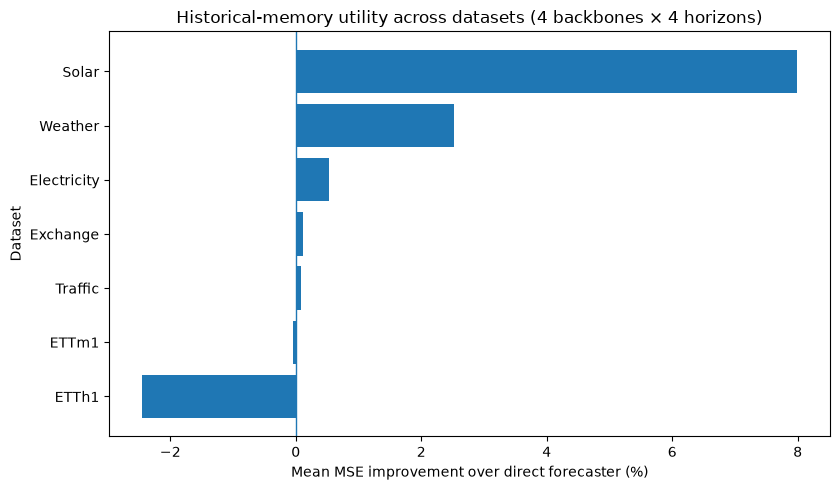

In [15]:
# Figure 1: dataset regime spectrum.
plot_df = dataset_summary.sort_values(
    "MeanMSEGain_pct",
    ascending=True,
)

fig, ax = plt.subplots(
    figsize=(8.5, 5.0)
)

ax.barh(
    plot_df["Dataset"],
    plot_df["MeanMSEGain_pct"],
)

ax.axvline(
    0.0,
    linewidth=1.0,
)

ax.set_xlabel(
    "Mean MSE improvement over direct forecaster (%)"
)

ax.set_ylabel(
    "Dataset"
)

ax.set_title(
    "Historical-memory utility across datasets (4 backbones × 4 horizons)"
)

fig.tight_layout()

fig.savefig(
    OUT_DIR / "dataset_regime_spectrum.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()


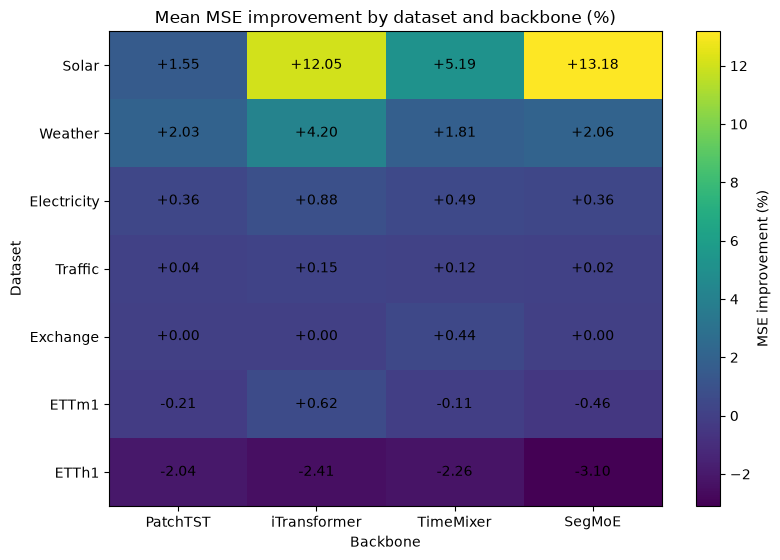

In [16]:
# Figure 2: dataset × backbone mean-gain matrix.
matrix = (
    dataset_backbone
    .pivot(
        index="Dataset",
        columns="Backbone",
        values="MeanMSEGain_pct",
    )
    .reindex(
        index=DATASETS,
        columns=BACKBONES,
    )
)

fig, ax = plt.subplots(
    figsize=(8.2, 5.7)
)

im = ax.imshow(
    matrix.to_numpy(
        dtype=float
    ),
    aspect="auto",
)

ax.set_xticks(
    np.arange(
        len(matrix.columns)
    ),
    labels=matrix.columns,
)

ax.set_yticks(
    np.arange(
        len(matrix.index)
    ),
    labels=matrix.index,
)

ax.set_xlabel(
    "Backbone"
)

ax.set_ylabel(
    "Dataset"
)

ax.set_title(
    "Mean MSE improvement by dataset and backbone (%)"
)

for i in range(
    matrix.shape[0]
):
    for j in range(
        matrix.shape[1]
    ):
        value = matrix.iloc[
            i,
            j,
        ]

        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:+.2f}",
                ha="center",
                va="center",
            )

fig.colorbar(
    im,
    ax=ax,
    label="MSE improvement (%)",
)

fig.tight_layout()

fig.savefig(
    OUT_DIR / "dataset_backbone_gain_matrix.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()


## 14. Sanity-check discovered aggregates against prior records

허용 오차는 artifact 버전 차이를 감안해 0.15 percentage point로 둡니다.
이 표에서 큰 mismatch가 있으면 source-selection audit를 먼저 확인합니다.


In [17]:
sanity_rows = []

# 3-backbone comparison.
for _, ref in PRIOR_3B_REFERENCE.iterrows():
    dataset = ref["Dataset"]

    grp = conditions[
        (conditions["Dataset"] == dataset)
        & (conditions["Backbone"].isin([
            "PatchTST",
            "iTransformer",
            "TimeMixer",
        ]))
    ]

    found_mean = (
        float(grp["MSEGain_pct"].mean())
        if len(grp)
        else np.nan
    )

    sanity_rows.append({
        "Dataset": dataset,
        "Group": "Prior 3 backbones",
        "FoundConditions": len(grp),
        "ExpectedConditions": int(ref["Conditions"]),
        "FoundMeanGain_pct": found_mean,
        "ReferenceMeanGain_pct": float(ref["MeanMSEGain_pct"]),
        "AbsDiff_pp": abs(
            found_mean
            - float(ref["MeanMSEGain_pct"])
        ) if np.isfinite(found_mean) else np.nan,
        "FoundWins": int((grp["MSEGain_pct"] > 0).sum()),
        "ReferenceWins": int(ref["Wins"]),
    })

# Seg-MoE comparison.
for _, ref in SEGMOE_REFERENCE.iterrows():
    dataset = ref["Dataset"]

    grp = conditions[
        (conditions["Dataset"] == dataset)
        & (conditions["Backbone"] == "SegMoE")
    ]

    found_mean = (
        float(grp["MSEGain_pct"].mean())
        if len(grp)
        else np.nan
    )

    sanity_rows.append({
        "Dataset": dataset,
        "Group": "SegMoE",
        "FoundConditions": len(grp),
        "ExpectedConditions": int(ref["Conditions"]),
        "FoundMeanGain_pct": found_mean,
        "ReferenceMeanGain_pct": float(ref["MeanMSEGain_pct"]),
        "AbsDiff_pp": abs(
            found_mean
            - float(ref["MeanMSEGain_pct"])
        ) if np.isfinite(found_mean) else np.nan,
        "FoundWins": int((grp["MSEGain_pct"] > 0).sum()),
        "ReferenceWins": int(ref["Wins"]),
    })

sanity = pd.DataFrame(
    sanity_rows
)

sanity["Status"] = np.where(
    (sanity["FoundConditions"] == sanity["ExpectedConditions"])
    & (sanity["AbsDiff_pp"] <= 0.15),
    "PASS",
    "CHECK",
)

display(sanity)

sanity.to_csv(
    OUT_DIR / "sanity_reference_check.csv",
    index=False,
)


failed_sanity = sanity[
    sanity["Status"] != "PASS"
].copy()

if len(failed_sanity):
    print("\nSANITY CHECK FAILURES:")
    display(failed_sanity)

    print("\nSelected source provenance for failed datasets:")

    failed_datasets = set(
        failed_sanity[
            "Dataset"
        ].astype(
            str
        )
    )

    provenance_debug = conditions[
        conditions[
            "Dataset"
        ].isin(
            failed_datasets
        )
    ][
        [
            "Dataset",
            "Backbone",
            "Horizon",
            "MSEGain_pct",
            "ExperimentFamily",
            "SourcePath",
        ]
    ].sort_values(
        [
            "Dataset",
            "Backbone",
            "Horizon",
        ]
    )

    display(
        provenance_debug
    )

    if STRICT_SANITY:
        raise RuntimeError(
            "Protocol-locked meta-analysis is not certified because "
            f"{len(failed_sanity)} frozen sanity references did not match. "
            "Inspect source provenance before using aggregate figures."
        )
else:
    print(
        "PASS: all frozen 3-backbone and Seg-MoE aggregate sanity references match."
    )


,Dataset,Group,FoundConditions,ExpectedConditions,FoundMeanGain_pct,ReferenceMeanGain_pct,AbsDiff_pp,FoundWins,ReferenceWins,Status
0,Solar,Prior 3 backbones,12,12,6.263439,6.263000,4.391630e-04,12,12,PASS
1,Weather,Prior 3 backbones,12,12,2.681605,2.682000,3.951810e-04,12,12,PASS
2,Electricity,Prior 3 backbones,12,12,0.577589,0.577000,5.892787e-04,11,11,PASS
3,Traffic,Prior 3 backbones,12,12,0.101656,0.101656,9.446877e-08,10,10,PASS
4,Exchange,Prior 3 backbones,12,12,0.147330,0.147000,3.296662e-04,1,1,PASS
5,ETTm1,Prior 3 backbones,12,12,0.099327,0.099000,3.270897e-04,7,7,PASS
6,ETTh1,Prior 3 backbones,12,12,-2.235568,-2.236000,4.323447e-04,0,0,PASS
7,Solar,SegMoE,4,4,13.179044,13.179000,4.448242e-05,4,4,PASS
8,Weather,SegMoE,4,4,2.058731,2.059000,2.688313e-04,4,4,PASS
9,Electricity,SegMoE,4,4,0.359577,0.360000,4.225745e-04,4,4,PASS


PASS: all frozen 3-backbone and Seg-MoE aggregate sanity references match.


## 15. Final paper-oriented report


In [18]:
print("=" * 118)
print("EXPERIMENT 37 v3 — PROVENANCE-RECOVERED FOUR-BACKBONE × DATASET META-ANALYSIS")
print("=" * 118)

print(
    f"Condition coverage: {len(conditions)}/{EXPECTED_CONDITIONS}"
)

if len(missing) == 0:
    print("Coverage status: COMPLETE")
else:
    print(
        f"Coverage status: INCOMPLETE — {len(missing)} conditions missing"
    )

print("\nDataset regime spectrum:")

for _, r in dataset_summary.iterrows():
    print(
        f"{r['Dataset']:12s} | "
        f"mean gain={r['MeanMSEGain_pct']:+7.3f}% | "
        f"wins={int(r['Wins']):2d}/{int(r['Conditions']):2d} | "
        f"known-sig={int(r['SigKnownConditions'])}/{int(r['Conditions'])} | "
        f"known sig+={r['KnownSigWins']} | "
        f"known sig-={r['KnownSigLosses']} | "
        f"{r['Regime']}"
    )

print("\nBackbone summary:")

for _, r in backbone_summary.iterrows():
    print(
        f"{r['Backbone']:13s} | "
        f"mean gain={r['MeanMSEGain_pct']:+7.3f}% | "
        f"wins={int(r['Wins']):2d}/{int(r['Conditions']):2d} | "
        f"losses={int(r['Losses']):2d}"
    )

print("\nETTm1 previous 3-backbone verification:")

if len(ettm1_old) == 12:
    print(
        f"Found 12/12 conditions; "
        f"wins={int((ettm1_old['MSEGain_pct'] > 0).sum())}/12; "
        f"mean gain={ettm1_old['MSEGain_pct'].mean():+.3f}%."
    )
else:
    print(
        f"Only {len(ettm1_old)}/12 previous ETTm1 conditions were discovered."
    )

print("\nSaved tables:")
for fn in [
    "condition_level_selected.csv",
    "dataset_backbone_summary.csv",
    "dataset_summary_4backbones.csv",
    "backbone_summary.csv",
    "horizon_summary.csv",
    "sanity_reference_check.csv",
]:
    print(" -", OUT_DIR / fn)

print("\nSaved figures:")
for fn in [
    "dataset_regime_spectrum.png",
    "dataset_backbone_gain_matrix.png",
]:
    print(" -", OUT_DIR / fn)

print(
    "\nInterpretation rule: do not claim universal improvement. "
    "Use the four-backbone results to characterize strong-positive, "
    "near-neutral/calibration-sensitive, and negative historical-utility regimes."
)


EXPERIMENT 37 v3 — PROVENANCE-RECOVERED FOUR-BACKBONE × DATASET META-ANALYSIS
Condition coverage: 112/112
Coverage status: COMPLETE

Dataset regime spectrum:
Solar        | mean gain= +7.992% | wins=16/16 | known-sig=4/16 | known sig+=4 | known sig-=0 | Strong positive
Weather      | mean gain= +2.526% | wins=16/16 | known-sig=16/16 | known sig+=16 | known sig-=0 | Positive
Electricity  | mean gain= +0.523% | wins=15/16 | known-sig=12/16 | known sig+=10 | known sig-=0 | Positive
Exchange     | mean gain= +0.110% | wins= 1/16 | known-sig=4/16 | known sig+=0 | known sig-=0 | Weak positive
Traffic      | mean gain= +0.082% | wins=14/16 | known-sig=16/16 | known sig+=13 | known sig-=1 | Weak positive
ETTm1        | mean gain= -0.039% | wins= 7/16 | known-sig=16/16 | known sig+=3 | known sig-=5 | Near neutral
ETTh1        | mean gain= -2.452% | wins= 0/16 | known-sig=16/16 | known sig+=0 | known sig-=14 | Negative

Backbone summary:
iTransformer  | mean gain= +2.215% | wins=18/28 | losses= 